# Parameter Tuning

### How does GESSO behave under weak/strong spatial smoothing and low pathway coverage?

Here we investigate the impact of spatial smoothing and pathway coverage on GESSO outputs.

1. **Spatial smoothing strength.** GESSO regularizes the gene set
   activity score (GAS) with a graph Laplacian. `beta` controls how much weight
   the spatial smoothness term carries. We sweep `beta` from `0` (no spatial smoothing) to `1` (only spatial) and measure how well sharp tissue boundaries are preserved.
2. **Pathway coverage.** Some technologies measure only
   a few hundred to a few thousand genes, so a pathway with hundreds of genes may be represented by only a few.

### Imports

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

project_directory = Path("__notebook__").resolve().parent.parent
sys.path.append(str(project_directory))

from gesso import GESSO

BETAS = [0.0, 0.2, 0.33, 0.5, 0.8, 1.0]
DEFAULT_BETA = 0.33
N_JOBS = 40

---
## Part 1: Spatial smoothing strength (`beta`)

GESSO solves a graph Laplacian-regularized rank-one decomposition. Written
loosely, it minimizes a combination of a data fidelity term and a
spatial smoothness term, with `beta` trading the two off:

$$\text{objective}(\beta) \;=\; (1-\beta)\,\text{(data fidelity)} \;+\; \beta\,\text{(spatial smoothness)}$$

At `beta = 0` GESSO ignores spatial information entirely and returns the purely
data-driven component.

At `beta = 1` the data term drops out completely. This setting should never be used.

We quantify this with the boundary contrast metric on the Stereo-seq E12.5
mouse embryo which has discrete anatomical annotations.

### Load the Stereo-seq E12.5 mouse embryo dataset

In [2]:
stereoseq_dir = Path("/users/ayang103/data/Project/SPLAGE/ST_Data/StereoSeq_Mouse")
pathways_dir = Path("/users/ayang103/data/Project/SPLAGE/Target_Pathway_List/PathwaysTable")

expression_rds = stereoseq_dir / "E12.5.gene.express.mat.Rds"
locations_rds = stereoseq_dir / "E12.5.location.Rds"
full_pathways_csv = pathways_dir / "StereoSeq.MouseEmbryo.PathwaysTable.1006.csv"
for p in (expression_rds, locations_rds, full_pathways_csv):
    assert p.exists(), p

expression_df = pyreadr.read_r(str(expression_rds))[None]
expression_df.columns.name = None
expression_df.index.name = None
expression_df = expression_df.T

loc_full = pyreadr.read_r(str(locations_rds))[None]
loc_full.columns.name = None
loc_full.index.name = None
locations_df = loc_full[["x", "y"]].copy()
anno = loc_full["anno"].astype(str)
expression_df.index = locations_df.index

We focus on four organ-specific gene sets.

In [3]:
full_pathways_df = pd.read_csv(full_pathways_csv, index_col=0)
full_pathways_df.columns.name = None
full_pathways_df.index.name = None
organ_genesets = {
    "GOBP_HEART_DEVELOPMENT": ["Heart"],
    "MANNO_MIDBRAIN_NEUROTYPES_HNPROG": ["Brain"],
    "AIZARANI_LIVER_C11_HEPATOCYTES_1": ["Liver"],
    "GOBP_EMBRYONIC_SKELETAL_SYSTEM_DEVELOPMENT": [
        "Cartilage primordium", "Jaw and tooth", "Connective tissue",
        "Meninges", "Dorsal root ganglion",
    ],
}
focal_genesets = list(organ_genesets)
genesets_df = full_pathways_df[focal_genesets]

### Compute GAS across the full `beta` sweep

In [4]:
model = GESSO(
    expression_df=expression_df,
    locations_df=locations_df,
    genesets_df=genesets_df,
    k=20,
)
gas_by_beta = {}
for beta in BETAS:
    report = model.compute_gas(
        genesets=focal_genesets,
        beta=beta,
        compute_method="lowres",
        partition_method="stratified_kmeans",
        n_partitions=10,
        n_jobs=N_JOBS,
        store_gene_contributions=False,
        verbose=False,
    )
    gas_by_beta[beta] = report.gas_df()

### Heart-specific GAS as `beta` increases

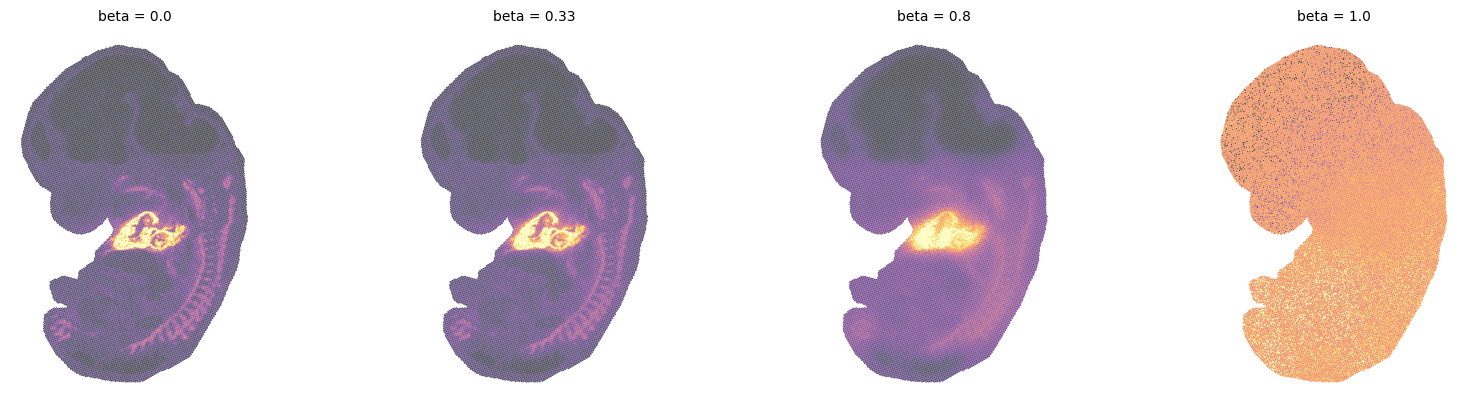

In [5]:
show_gs = "GOBP_HEART_DEVELOPMENT"
show_betas = [0.0, 0.33, 0.8, 1.0]
coords = locations_df[["x", "y"]].to_numpy(float)

fig, axes = plt.subplots(1, len(show_betas), figsize=(4.2 * len(show_betas), 4.2))
for ax, beta in zip(axes, show_betas):
    v = gas_by_beta[beta][show_gs].to_numpy()
    vmin, vmax = np.percentile(v, 1), np.percentile(v, 99)
    ax.scatter(coords[:, 0], coords[:, 1], c=v, cmap="inferno",
               s=2, marker=".", linewidths=0, vmin=vmin, vmax=vmax)
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(f"beta = {beta}", fontsize=10)
fig.tight_layout()
display(fig)
plt.close(fig)

### Boundary contrast vs `beta`

For an organ gene set with GAS $a_i$ at spot $i$, build a spatial kNN graph over
the spots and split neighbor pairs into:

- interior edges (both spots inside the organ)
- border edges (exactly one spot inside the organ)

Let boundary contrast be the ratio of the mean absolute GAS difference across
border edges to that within the interior:

$$\text{Boundary Contrast} \;=\; \frac{\operatorname{mean}_{(i,j)\,\in\,\text{border}} |a_i - a_j|}{\operatorname{mean}_{(i,j)\,\in\,\text{interior}} |a_i - a_j|}.$$

A score that stays smooth inside a region but jumps at its border has a high
contrast (> 1). An over-smoothed or degenerate score bleeds across the boundary,
and the ratio goes toward 1.

In [6]:
def boundary_contrast(scores, coords, in_region, k=15):
    tree = cKDTree(coords)
    _, idx = tree.query(coords, k=k + 1, workers=-1)
    nbr = idx[:, 1:]
    dscore = np.abs(scores[:, None] - scores[nbr])
    inside_i = in_region[:, None]
    inside_j = in_region[nbr]
    interior = inside_i & inside_j          # both endpoints inside the organ
    border = inside_i ^ inside_j            # exactly one endpoint inside
    if not interior.any() or not border.any():
        return np.nan
    return float(dscore[border].mean() / dscore[interior].mean())

# boundary contrast vs beta per organ gene set
bc_rows = []
for beta in BETAS:
    for gs, regions in organ_genesets.items():
        in_region = anno.isin(regions).to_numpy()
        bc = boundary_contrast(gas_by_beta[beta][gs].to_numpy(), coords, in_region, k=15)
        bc_rows.append({"beta": beta, "geneset": gs, "boundary_contrast": bc})
bc_df = pd.DataFrame(bc_rows)
bc_wide = bc_df.pivot(index="beta", columns="geneset", values="boundary_contrast")
bc_wide["mean"] = bc_wide.mean(axis=1)
display(bc_wide.round(3))

geneset,AIZARANI_LIVER_C11_HEPATOCYTES_1,GOBP_EMBRYONIC_SKELETAL_SYSTEM_DEVELOPMENT,GOBP_HEART_DEVELOPMENT,MANNO_MIDBRAIN_NEUROTYPES_HNPROG,mean
beta,,,,,
0.00,1.050,1.188,1.941,1.638,1.454
0.20,1.068,1.189,1.954,1.642,1.463
0.33,1.086,1.188,1.955,1.642,1.468
0.50,1.120,1.178,1.930,1.633,1.465
0.80,1.226,1.034,1.519,1.498,1.319
1.00,0.969,1.031,0.977,1.020,1.000


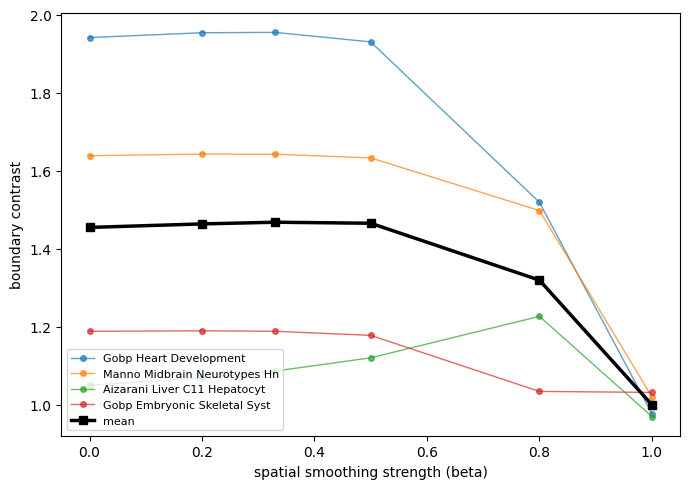

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
for gs in focal_genesets:
    ax.plot(bc_wide.index, bc_wide[gs], marker="o", ms=4, lw=1, alpha=0.7,
            label=gs.replace("_", " ").title()[:28])
ax.plot(bc_wide.index, bc_wide["mean"], marker="s", ms=6, lw=2.5, color="black", label="mean")
ax.set_xlabel("spatial smoothing strength (beta)")
ax.set_ylabel("boundary contrast")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
display(fig)
plt.close(fig)

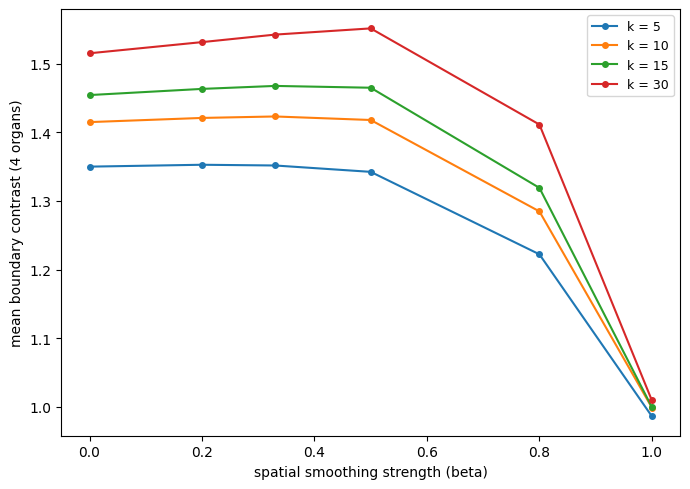

In [8]:
k_values = [5, 10, 15, 30]
rows = []
for k in k_values:
    for beta in BETAS:
        vals = [
            boundary_contrast(gas_by_beta[beta][gs].to_numpy(), coords,
                              anno.isin(regions).to_numpy(), k=k)
            for gs, regions in organ_genesets.items()
        ]
        rows.append({"beta": beta, "k": k, "mean_boundary_contrast": np.nanmean(vals)})
bc_k_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 5))
for k in k_values:
    sub = bc_k_df[bc_k_df["k"] == k]
    ax.plot(sub["beta"], sub["mean_boundary_contrast"], marker="o", ms=4, label=f"k = {k}")
ax.set_xlabel("spatial smoothing strength (beta)")
ax.set_ylabel("mean boundary contrast (4 organs)")
ax.legend(fontsize=9)
fig.tight_layout()
display(fig)
plt.close(fig)

### Region recovery (AUC) vs `beta`
We plot the mean AUC over the four organs as a function of `beta`.

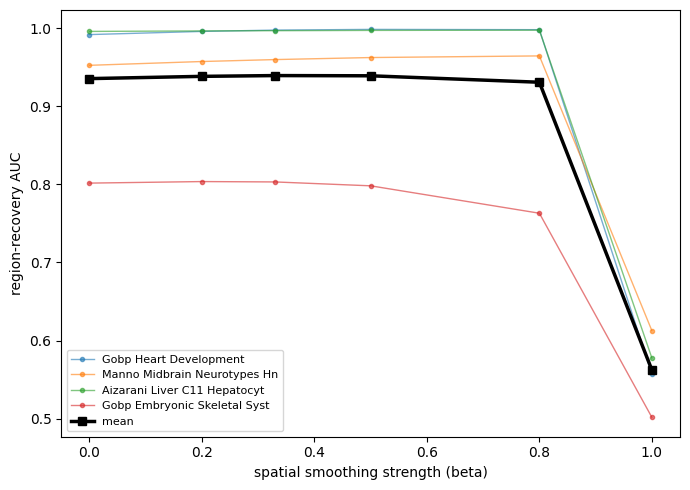

In [9]:
def single_feature_auc(x, y):
    x = np.asarray(x, float).reshape(-1, 1)
    if x.std() < 1e-12:
        return np.nan
    clf = LogisticRegression(penalty=None, max_iter=500, random_state=42).fit(x, y)
    return roc_auc_score(y, clf.predict_proba(x)[:, 1])


auc_rows = []
for beta in BETAS:
    for gs, regions in organ_genesets.items():
        y = anno.isin(regions).astype(int).to_numpy()
        auc = single_feature_auc(gas_by_beta[beta][gs].to_numpy(), y)
        auc_rows.append({"beta": beta, "geneset": gs, "auc": auc})
auc_df = pd.DataFrame(auc_rows)
auc_mean = auc_df.groupby("beta")["auc"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
for gs in focal_genesets:
    sub = auc_df[auc_df["geneset"] == gs]
    ax.plot(sub["beta"], sub["auc"], marker="o", ms=3, lw=1, alpha=0.6,
            label=gs.replace("_", " ").title()[:28])
ax.plot(auc_mean.index, auc_mean.values, marker="s", ms=6, lw=2.5, color="black", label="mean")
ax.set_xlabel("spatial smoothing strength (beta)")
ax.set_ylabel("region-recovery AUC")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
display(fig)
plt.close(fig)

---
## Part 2: Low pathway coverage exploration

Targeted panels (Xenium, CosMx, MERSCOPE) measure only a few hundred to a few thousand genes, so a pathway with hundreds of genes may be represented by only a few.

To explore, we use the CosMx NSCLC targeted panel and the epithelial/tumor "Tumor Core" gene set (`TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL`, 65 genes), scoring how well its GAS recovers the Tumor core tissue region.

In [10]:
cosmx_dir = Path("/users/ayang103/data/Project/SPLAGE/ST_Data/CosMx_ECM3D")
cosmx_pathways_csv = Path(
    "/users/ayang103/data/Project/SPLAGE/Target_Pathway_List/PathwaysTable/used_geneset"
    "/CosMx.NSCLC3D.PathwaysTable.0702.csv"
)
count_rds = cosmx_dir / "section_22_Count.Rds"
metadata_rds = cosmx_dir / "section_22_Metadata.Rds"
for p in (count_rds, metadata_rds, cosmx_pathways_csv):
    assert p.exists(), p

cosmx_expr = pyreadr.read_r(str(count_rds))[None]
cosmx_expr.columns.name = None
cosmx_expr.index.name = None
cosmx_expr = cosmx_expr.T

cosmx_meta = pyreadr.read_r(str(metadata_rds))[None]
cosmx_meta.columns.name = None
cosmx_meta.index.name = None
cosmx_loc = cosmx_meta[["x_2D_px", "y_2D_px"]].rename(columns={"x_2D_px": "x", "y_2D_px": "y"})
niche_3d = cosmx_meta["niches_3D"]

tumor_pw = "TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL"
cosmx_pathways = pd.read_csv(cosmx_pathways_csv, index_col=0, usecols=["Unnamed: 0", tumor_pw])
tumor_genes_full = [g for g in cosmx_pathways.index[cosmx_pathways[tumor_pw] == 1] if g in cosmx_expr.columns]

### Coverage ablation

We randomly retain a decreasing fraction of the gene set's genes, down to as few as 3 genes, repeating each coverage level 10 times to average over which genes happen to survive. For every subset we recompute the GAS and score how well it recovers the Tumor core region (single-feature AUC).

In [11]:
cosmx_model = GESSO(
    expression_df=cosmx_expr,
    locations_df=cosmx_loc,
    k=20,
    normalize_counts_method="normalize-log1p",
)

cover_rates = [1.0, 0.8, 0.6, 0.4, 0.2, 0.1, 0.07, 0.04]
n_repeats = 10
rng = np.random.default_rng(0)

n_full = len(tumor_genes_full)
subsets = {}
subset_meta = []
for rate in cover_rates:
    n_keep = max(round(n_full * rate), 1)
    reps = 1 if rate == 1.0 else n_repeats  # full set is deterministic
    for r in range(reps):
        genes = list(rng.choice(tumor_genes_full, size=n_keep, replace=False))
        name = f"cov{rate}_r{r}"
        subsets[name] = genes
        subset_meta.append({"name": name, "rate": rate, "n_keep": n_keep})

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # coverage warnings are demonstrated separately below
    cov_report = cosmx_model.compute_gas(
        genesets_dict=subsets,
        beta=DEFAULT_BETA,
        compute_method="lowres",
        n_partitions=10,
        n_jobs=N_JOBS,
        store_gene_contributions=False,
        verbose=False,
    )
cov_gas = cov_report.gas_df()

In [12]:
y_series = (niche_3d[niche_3d.notna()] == "Tumor core")
labeled = cov_gas.index.intersection(y_series.index)
y_region = y_series.loc[labeled].astype(int).to_numpy()

meta_df = pd.DataFrame(subset_meta)
meta_df["auc"] = [single_feature_auc(cov_gas.loc[labeled, n].to_numpy(), y_region) for n in meta_df["name"]]

cov_summary = (
    meta_df.groupby("n_keep")["auc"]
    .agg(["mean", "std", "count"])
    .sort_index(ascending=False)
)
cov_summary["coverage_pct"] = 100 * cov_summary.index / len(tumor_genes_full)
display(cov_summary.round(3))

,mean,std,count,coverage_pct
n_keep,,,,
65,0.893,NaN,1,100.000
52,0.890,0.007,10,80.000
39,0.878,0.020,10,60.000
26,0.866,0.017,10,40.000
13,0.791,0.111,10,20.000
6,0.817,0.056,10,9.231
5,0.761,0.109,10,7.692
3,0.733,0.104,10,4.615


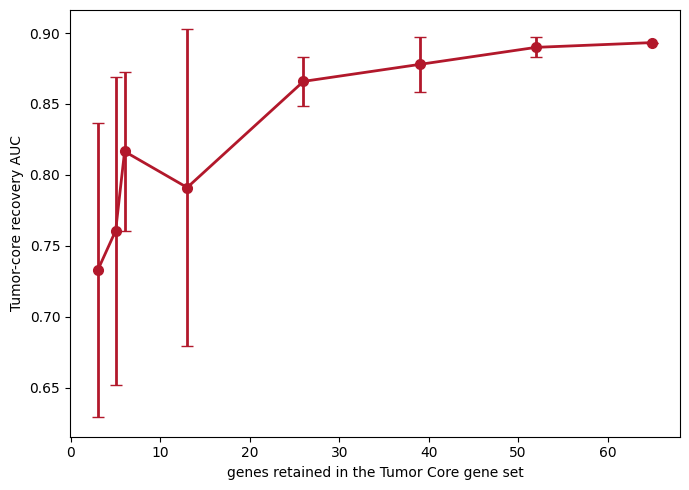

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
xs = cov_summary.index.to_numpy()
ax.errorbar(xs, cov_summary["mean"], yerr=cov_summary["std"].fillna(0),
            marker="o", ms=7, lw=2, capsize=4, color="#b2182b")
ax.set_xlabel("genes retained in the Tumor Core gene set")
ax.set_ylabel("Tumor-core recovery AUC")
fig.tight_layout()
display(fig)
plt.close(fig)

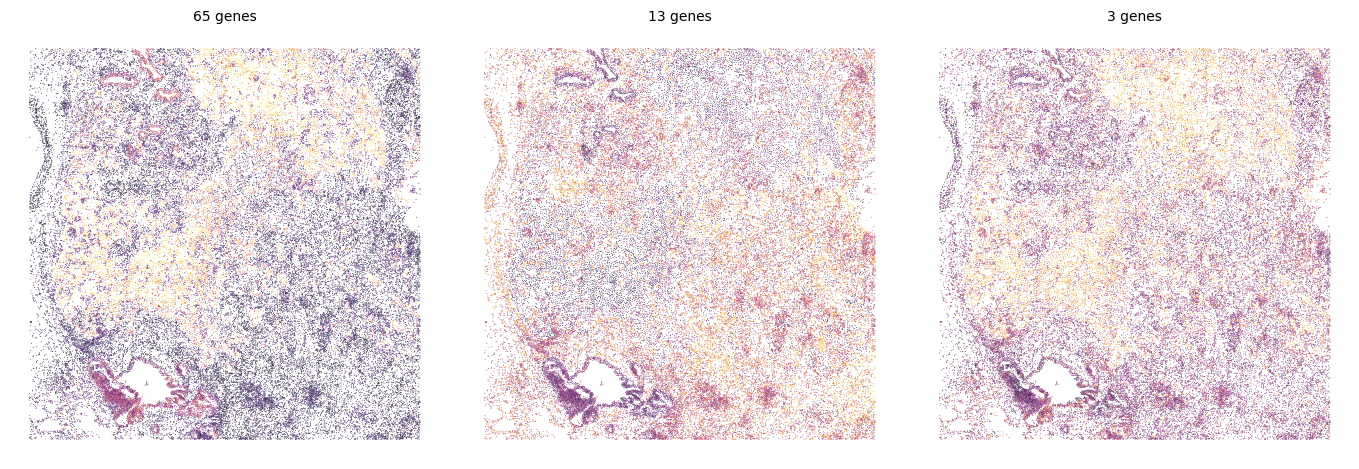

In [14]:
cc = cosmx_loc.loc[cov_gas.index, ["x", "y"]].to_numpy(float)
panel_specs = [
    ("cov1.0_r0", f"{len(tumor_genes_full)} genes"),
    ("cov0.2_r0", "13 genes"),
    ("cov0.04_r0", "3 genes"),
]
fig, axes = plt.subplots(1, len(panel_specs), figsize=(4.6 * len(panel_specs), 4.6))
for ax, (name, label) in zip(axes, panel_specs):
    v = cov_gas[name].to_numpy()
    vmin, vmax = np.percentile(v, 1), np.percentile(v, 99)
    ax.scatter(cc[:, 0], cc[:, 1], c=v, cmap="inferno",
               s=1.5, marker=".", linewidths=0, vmin=vmin, vmax=vmax)
    ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(label, fontsize=10)
fig.tight_layout()
display(fig)
plt.close(fig)

### Warning behavior

GESSO will warn you automatically when a gene set is too sparsely covered. If fewer
than 5% of a gene set's genes are present in the data, `compute_gas` emits a
`UserWarning`.

In [ ]:
measured = tumor_genes_full[:3]
panel_genes = measured + [g for g in cosmx_expr.columns if g not in set(tumor_genes_full)]
panel_model = GESSO(
    expression_df=cosmx_expr[panel_genes],
    locations_df=cosmx_loc,
    k=20,
    normalize_counts_method="normalize-log1p",
    verbose=False,
)

_ = panel_model.compute_gas(
    genesets_dict={tumor_pw: tumor_genes_full},
    beta=DEFAULT_BETA, compute_method="lowres", n_partitions=10,
    n_jobs=N_JOBS, store_gene_contributions=False, verbose=False,
)

/tmp/ipykernel_2940470/1764332296.py:13: UserWarning: Gene set 'TRAVAGLINI_LUNG_ALVEOLAR_EPITHELIAL_TYPE_1_CELL': only 3/65 (4.62%) genes remain after filtering to genes in the dataset (< 5%). Activity scores for this gene set may be unreliable.
  _ = panel_model.compute_gas(
